<a href="https://colab.research.google.com/github/FahrulKhoiruzaki/Pembelajaran-Mesin-2026/blob/main/TG4_2440107020234_Fahrul_Khoiruzaki.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum 1 KMeans**

#### **Persiapan data**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


#### Seleksi Fitur

In [4]:
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


#### **Plot Data**

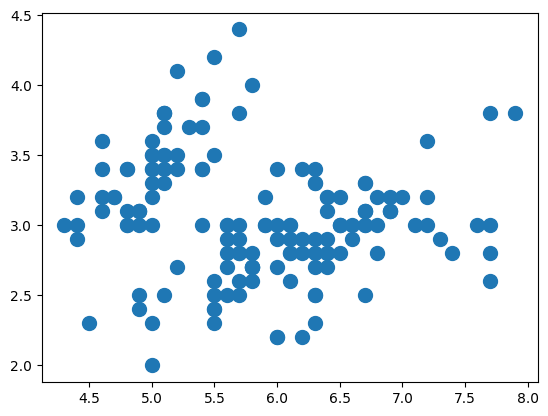

In [6]:
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

#### **Model KMeans**

In [7]:
from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

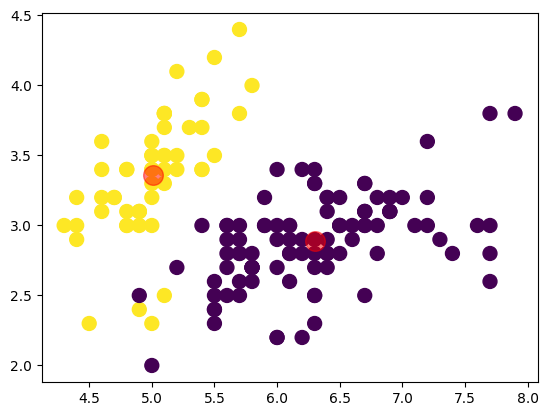

In [8]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [9]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


#### **Implementasi Metode Elbow**

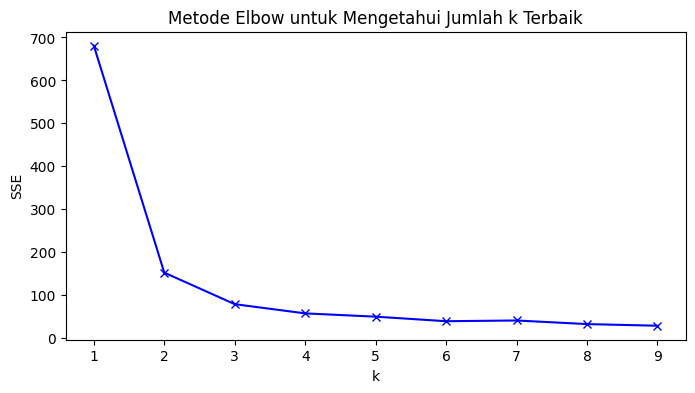

In [11]:
# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,10)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [12]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.4732732654949
k=5; SSE=49.86865426388461
k=6; SSE=39.251830892636775
k=7; SSE=40.96325881370092
k=8; SSE=32.54719999999998
k=9; SSE=28.75886541397412


# **Praktkum 2**

#### **Import Library**

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

#### **Pengantar KMeans**

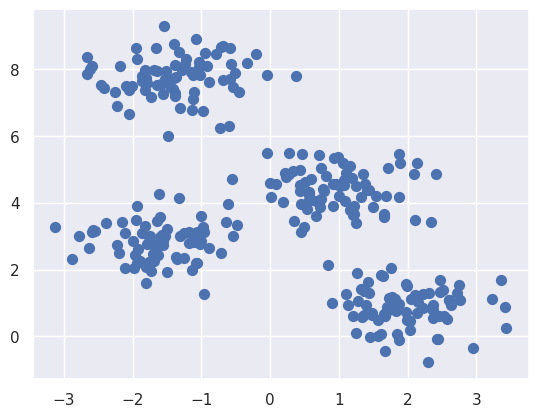

In [14]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [15]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

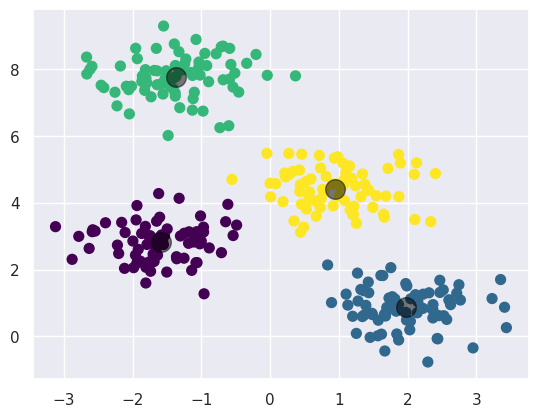

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

#### **Algoritma Expectation-Maximization**

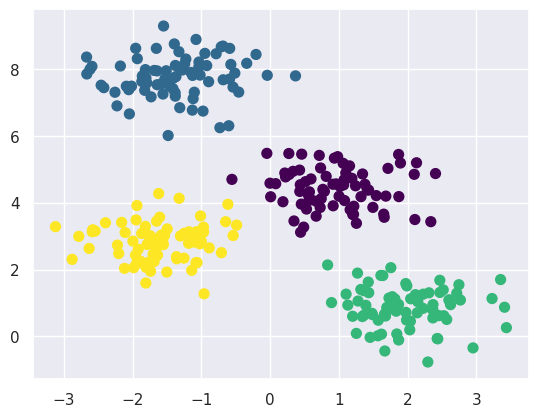

In [17]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

#### **Perubahan Random**

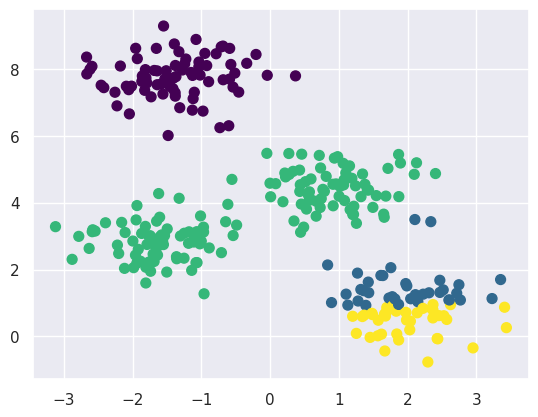

In [18]:
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

#### **Optimalisasi Jumlah Klaster**

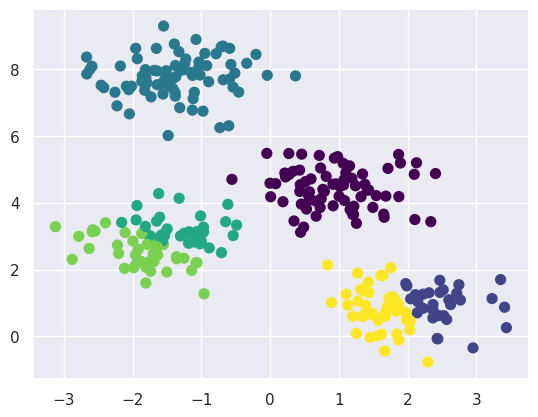

In [19]:
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

#### **Batas Klaster yang Tidak Selalu Linear**

In [20]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

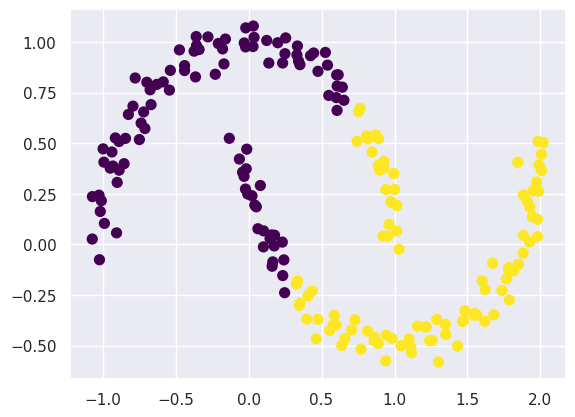

In [21]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


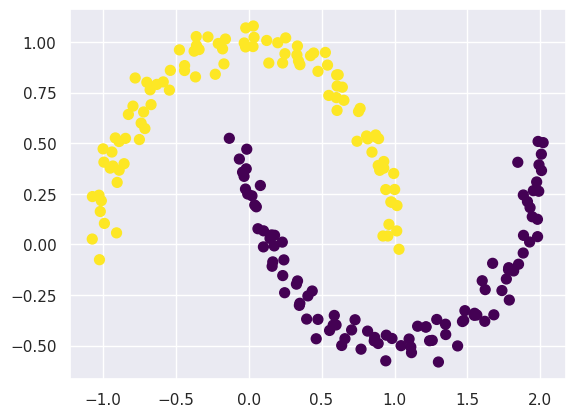

In [29]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

### **Contoh Kasus 1: Karakter Angka**

In [30]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [31]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

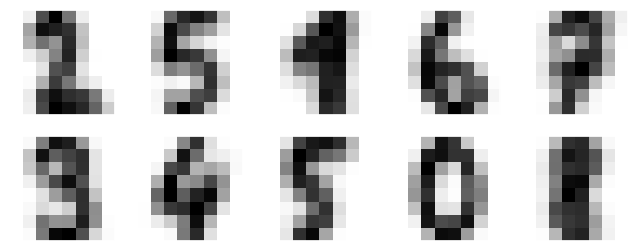

In [36]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [37]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [38]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

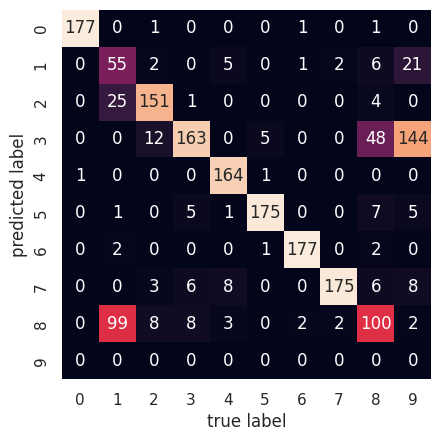

In [39]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [40]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

### **Kasus 2: Kompresi Citra**

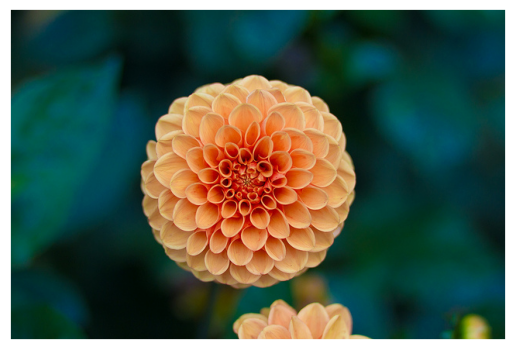

In [41]:
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [42]:
flower.shape

(427, 640, 3)

In [43]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [44]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

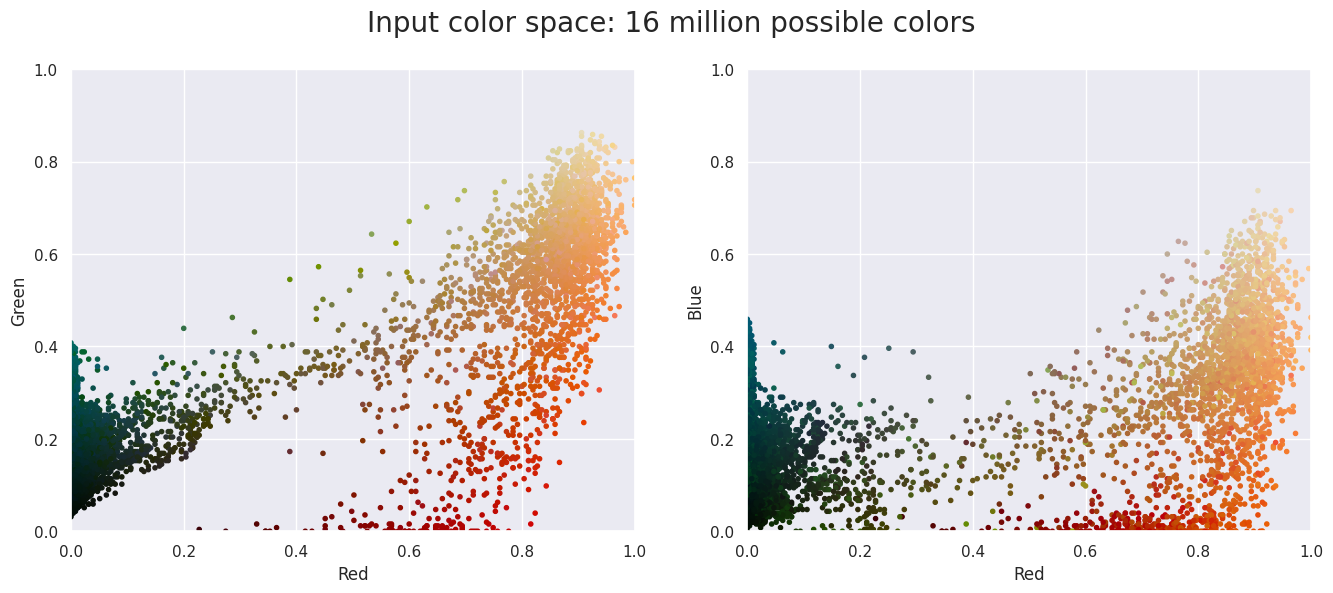

In [45]:
plot_pixels(data, title='Input color space: 16 million possible colors')

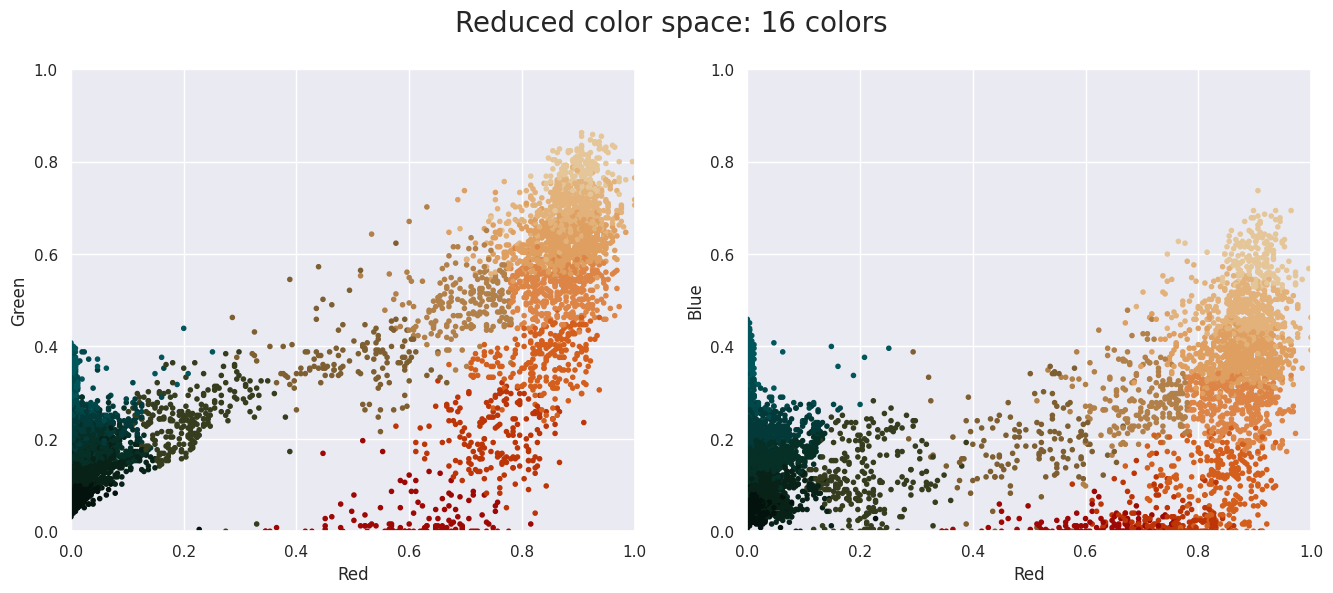

In [46]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

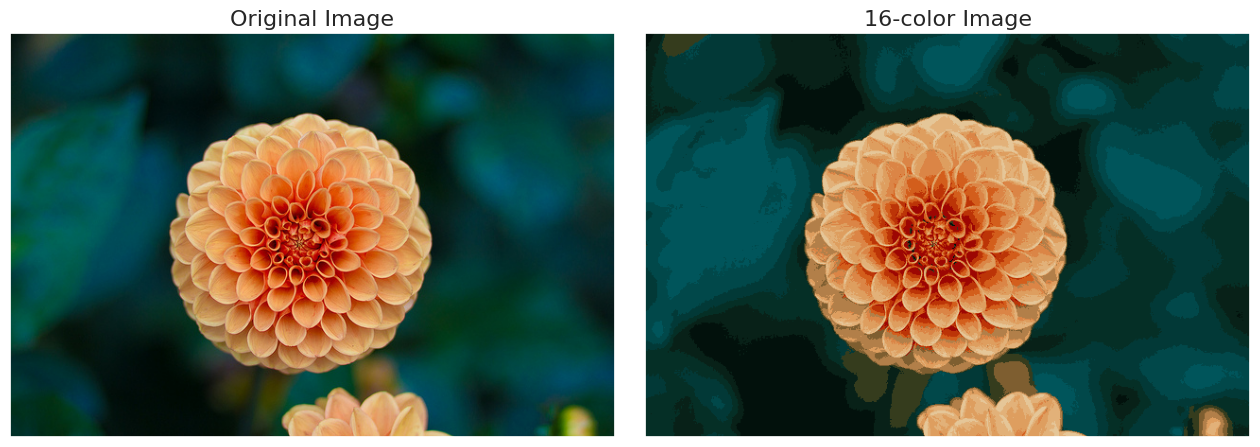

In [47]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# **Praktikum 3: Pembuatan Datases Sintetis**

In [49]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

#### **Visualisasikan Data**

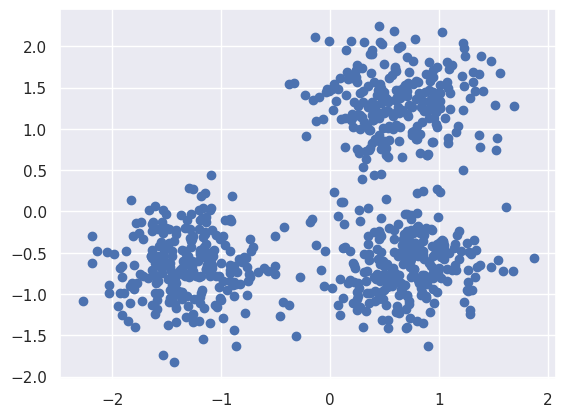

In [55]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

#### **Compute DBSCAN**

In [57]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


#### **Evaluasi Kualitas Klasterisasi**

In [58]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


#### **Visualisasi Hasil Klasterisasi**

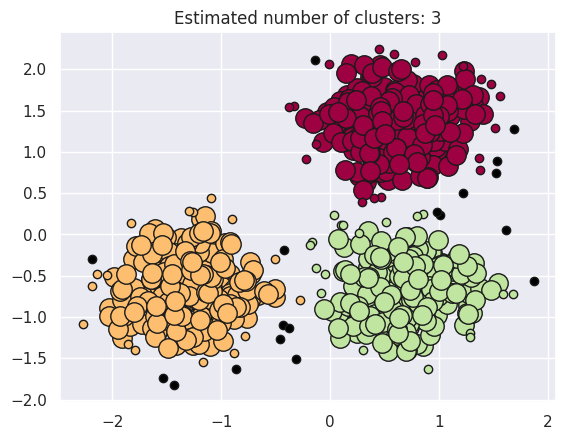

In [60]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# **Tugas K-Means**

#### **Membaca Dataset**

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### **Fitur Clustering**

In [63]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### **Plot Data**

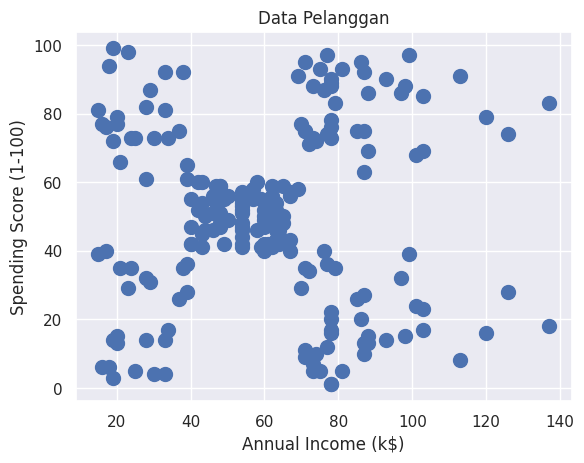

In [64]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=100)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Data Pelanggan')

plt.show()

#### **Jumlah K dengan Metode Elbow**

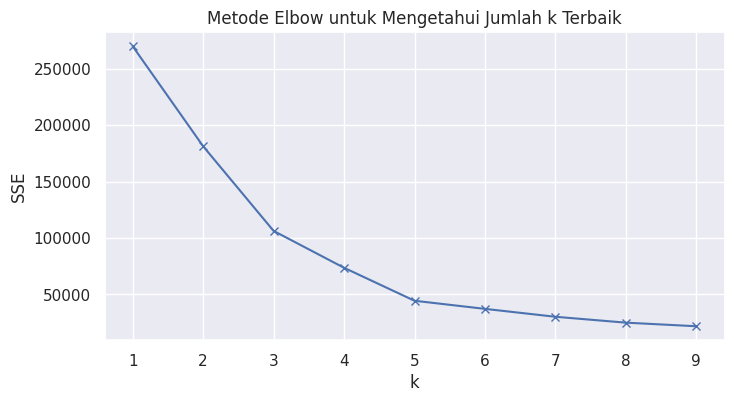

In [67]:
sse = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

# Plot metode Elbow
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [68]:
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=269981.28000000014
k=2; SSE=181363.59595959607
k=3; SSE=106348.37306211119
k=4; SSE=73679.78903948837
k=5; SSE=44448.45544793369
k=6; SSE=37265.86520484345
k=7; SSE=30259.657207285458
k=8; SSE=25050.832307547524
k=9; SSE=21862.09267218289


#### **Model K-Means**

In [70]:
cl_kmeans = KMeans(n_clusters=5, random_state=0, n_init=10)

y_kmeans = cl_kmeans.fit_predict(X)

#### **Visualisasi Hasil Clustering**

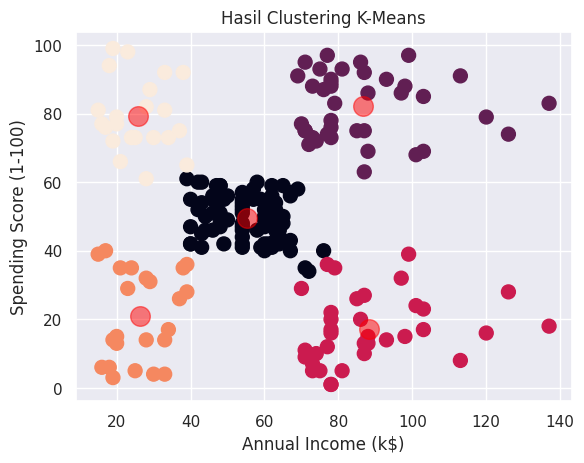

In [73]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=100, c=y_kmeans)

centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Hasil Clustering K-Means')

plt.show()

#### **Nilai SSE K-Means**

In [74]:
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 44448.45544793369


## **Jawaban Tugas K-Means**

- *Fitur yang digunakan:*<br>
Annual Income (K$) dan Spending Score (1-100)
- *Jumlah cluster terbaik:*<br>
5 Cluster

# **Tugas DBSCAN**

In [76]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, labels_true = make_moons(
    n_samples=1000,
    noise=0.05,
    random_state=0
)

X = StandardScaler().fit_transform(X)

#### **Viasulisasi**

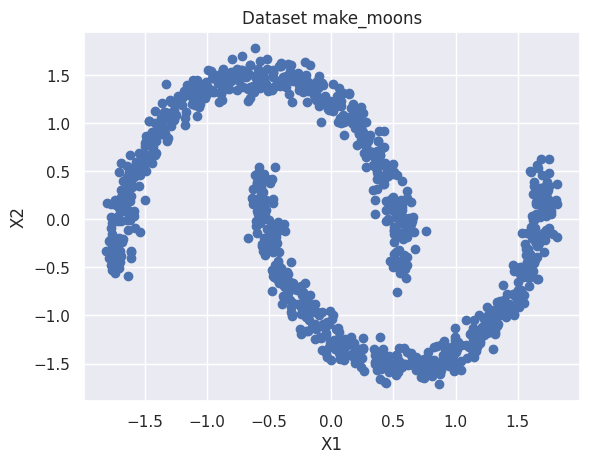

In [78]:
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Dataset make_moons')
plt.show()

#### **Menjalankan DBSCAN**

In [80]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5).fit(X)

labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


#### **Evaluasi DBSCAN**

In [81]:
from sklearn import metrics

print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


#### **Visualisasi Hasil DBSCAN**

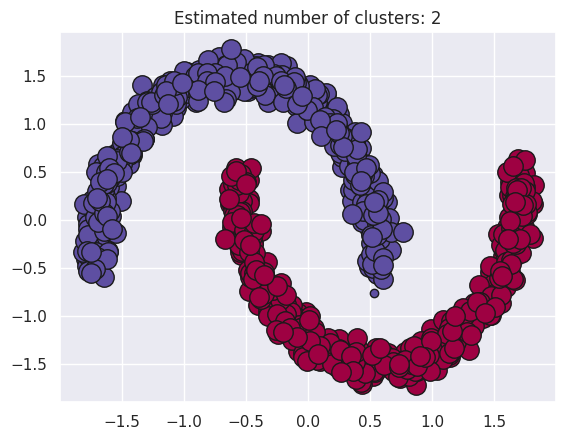

In [83]:
unique_labels = set(labels)

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):

    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]

    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14
    )

    xy = X[class_member_mask & ~core_samples_mask]

    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

#### **Eksperimen eps dan min_samples**

In [85]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN( eps=eps, min_samples=min_samples).fit(X)

        labels = db.labels_

        n_clusters_ = len(set(labels)) - (
            1 if -1 in labels else 0
        )
        n_noise_ = list(labels).count(-1)

        print(f"eps={eps}, "f"min_samples={min_samples}")
        print(f"Cluster={n_clusters_}, "f"Noise={n_noise_}")
        print(f"Homogeneity: "f"{metrics.homogeneity_score(labels_true, labels):.3f}")
        print(f"Completeness: "f"{metrics.completeness_score(labels_true, labels):.3f}")
        print(f"V-measure: "f"{metrics.v_measure_score(labels_true, labels):.3f}")
        print(f"ARI: "f"{metrics.adjusted_rand_score(labels_true, labels):.3f}")
        print(f"AMI: "f"{metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")

        if len(set(labels)) > 1 and len(set(labels)) < len(labels):
            print(f"Silhouette: "f"{metrics.silhouette_score(X, labels):.3f}")
        else:
            print("Silhouette: tidak dapat dihitung")

        print()

eps=0.05, min_samples=3
Cluster=67, Noise=197
Homogeneity: 0.804
Completeness: 0.155
V-measure: 0.260
ARI: 0.033
AMI: 0.246
Silhouette: 0.078

eps=0.05, min_samples=10
Cluster=0, Noise=1000
Homogeneity: 0.000
Completeness: 1.000
V-measure: 0.000
ARI: 0.000
AMI: 0.000
Silhouette: tidak dapat dihitung

eps=0.05, min_samples=20
Cluster=0, Noise=1000
Homogeneity: 0.000
Completeness: 1.000
V-measure: 0.000
ARI: 0.000
AMI: 0.000
Silhouette: tidak dapat dihitung

eps=0.1, min_samples=3
Cluster=3, Noise=18
Homogeneity: 0.983
Completeness: 0.708
V-measure: 0.824
ARI: 0.854
AMI: 0.823
Silhouette: 0.138

eps=0.1, min_samples=10
Cluster=9, Noise=63
Homogeneity: 0.939
Completeness: 0.358
V-measure: 0.519
ARI: 0.435
AMI: 0.517
Silhouette: 0.184

eps=0.1, min_samples=20
Cluster=6, Noise=844
Homogeneity: 0.157
Completeness: 0.153
V-measure: 0.155
ARI: 0.010
AMI: 0.152
Silhouette: -0.409

eps=0.3, min_samples=3
Cluster=2, Noise=0
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
ARI: 1.000
AMI: 1

Hasil eksperimen memperlihatkan jika perubaham nilai eps dan min_samples memengaruh jumlah klaster dan jumlah noise yang dihasilkan. Di eps yang kecil, julah noise lebih banyak karena radius pencarian tetangga lenbih kecil. Ketika nilai eps diperbesar, lebih banyak titik dapat bergabung ke dalam klaster jadi jumlah noise dapat berkurang

Perubahan min_samples juga memengaruhi pembentukan klaster. Nilai min_samples yang lebih besar membuat suatu titik membutuhkan lebih banyak tetangga untuk dianggap core sample.

Di parameter utama eps=0.2 dan min_samples=5, DBSCAN menghasilkan 2 klaster dengan 0 noise, dengan hasil evaluasi yang terlihat Homogeneity, Completeness, V-measure, ARI, dan AMI sebesar 1.000, juga Silhouette sebesar 0.392.